In [1]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "1"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

from tqdm.auto import tqdm
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from jax import grad, vmap, random
import optax
from seaborn import kdeplot
import wandb
from ot.lp import wasserstein_1d
import argparse

from triangular_transport.flows.flow_trainer import (
    NNTrainer,
)

from triangular_transport.flows.interpolants import (
    linear_interpolant,
    linear_interpolant_der,
    trig_interpolant,
    trig_interpolant_der,
    sigmoid_interpolant,
    sigmoid_interpolant_der,
)
from triangular_transport.flows.loss_functions import vec_field_loss
from triangular_transport.networks.flow_networks import MLP
from triangular_transport.flows.methods.sampling import inf_train_gen
from triangular_transport.flows.dataloaders import (
    standard_gaussian_reference_sampler,
)

from triangular_transport.kernels.kernel_tools import (
    get_gaussianRBF,
    vectorize_kfunc,
    get_sum_of_kernels,
)
from ksd import compute_ksd_jax, compute_ksd

plt.style.use("ggplot")

/home/verano13/miniconda3/envs/stochastic-interpolants/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
sample_no_list = [2**i for i in range(1, 15)]
sample_no_list.append(20000)
sample_no_list.append(30000)
sample_no_list.append(40000)
sample_no_list.append(50000)
sample_no_list.append(60000)
sample_no_list.append(70000)
sample_no_list.append(80000)
sample_no_list.append(90000)
sample_no_list.append(100000)

In [6]:
epochs = 8000
rng = np.random.RandomState(1)
key = random.PRNGKey(1)
key, key1, key2, key3, key4 = random.split(key, 5)
key, subkey1 = random.split(key, 2)
train_dim = 80000
batch_size = 2048
batch_size = min(batch_size, train_dim)
batch_size -= 1
steps_per_epoch = int(np.ceil(train_dim / batch_size))
steps = steps_per_epoch * epochs
print_every = 10000
yu_dimension = (1, 1)
target_data = inf_train_gen(data="banana", rng=rng, batch_size=train_dim)
dim = yu_dimension[0] + yu_dimension[1]
# hidden_layer_list = [256] * 4 if train_dim < 8000 else [1024] * 8
# hidden_layer_list = [512] * 6
# hidden_layer_list = [256] * 3
hidden_layer_list = [1024] * 8
model = MLP(
    key=key1,
    dim=dim,
    time_varying=True,
    w=hidden_layer_list,
    num_layers=len(hidden_layer_list) + 1,
    activation_fn=jax.nn.gelu,  # GeLU worked well
)
schedule = optax.warmup_cosine_decay_schedule(
    init_value=0.0,
    peak_value=1e-3,
    warmup_steps=2_000,
    decay_steps=steps,
    end_value=1e-5,
)
optimizer = optax.chain(
    optax.clip_by_global_norm(1.0), optax.adamw(schedule)
)

interpolant = trig_interpolant
interpolant_der = trig_interpolant_der
interpolant_args = {"t": None, "x1": None, "x0": None}

trainer = NNTrainer(
    target_density=None,
    model=model,
    optimizer=optimizer,
    interpolant=interpolant,
    interpolant_der=interpolant_der,
    reference_sampler=standard_gaussian_reference_sampler,
    loss=vec_field_loss,
    interpolant_args=interpolant_args,
    yu_dimension=yu_dimension,
)

trainer.train(
    train_data=target_data,
    train_dim=train_dim,
    batch_size=batch_size,
    steps=steps,
    x0_data=None,
    print_every=print_every,
)

Training neural network


  0%|          | 30/320000 [00:02<5:35:13, 15.91it/s] 

step = 0, train_loss = -0.0032579731196165085


  3%|▎         | 10041/320000 [00:37<18:02, 286.35it/s]

step = 10000, train_loss = -3.2105987071990967


...

 97%|█████████▋| 310040/320000 [16:59<00:32, 309.38it/s]

step = 310000, train_loss = -3.2405636310577393


100%|██████████| 320000/320000 [17:32<00:00, 304.14it/s]

step = 319999, train_loss = -2.962416410446167


MLP(
  layers=[
    Linear(
      weight=f32[1024,3],
      bias=f32[1024],
      in_features=3,
      out_features=1024,
      use_bias=True
    ),
    Linear(
      weight=f32[1024,1024],
      bias=f32[1024],
      in_features=1024,
      out_features=1024,
      use_bias=True
    ),
    Linear(
      weight=f32[1024,1024],
      bias=f32[1024],
      in_features=1024,
      out_features=1024,
      use_bias=True
    ),
    Linear(
      weight=f32[1024,1024],
      bias=f32[1024],
      in_features=1024,
      out_features=1024,
      use_bias=True
    ),
    Linear(
      weight=f32[1024,1024],
      bias=f32[1024],
      in_features=1024,
      out_features=1024,
      use_bias=True
    ),
    Linear(
      weight=f32[1024,1024],
      bias=f32[1024],
      in_features=1024,
      out_features=1024,
      use_bias=True
    ),
    Linear(
      weight=f32[1024,1024],
      bias=f32[1024],
      in_features=1024,
      out_features=1024,
      use_bias=True
    ),
    Linear(
     

In [11]:
nsamples = 20000
samps = np.load("rej_samples_1.npy")[
    rng.choice(100000, size=(nsamples,)), :
]
us_base = rng.randn(nsamples, 1)
print("About to calculate wd...")
base_wd = wasserstein_1d(
    us_base,
    samps,
)

wd_array = np.zeros(len(sample_no_list))
for i, sample_no in enumerate(sample_no_list):
    cond_samples = trainer.conditional_sample(
            cond_values=-1.0,
            nsamples=sample_no,
            u0_cond=None,
        )

    us_gen = cond_samples[:, 1:2]
    wd_array[i] = (
        wasserstein_1d(np.array(us_gen), samps)
        / base_wd
    )

About to calculate wd...


/tmp/ipykernel_2455918/110364500.py:21: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  wd_array[i] = (


In [12]:
rel_wd_array_mcmc = np.load("mcmc_results/rel_wd_array_mcmc.npy")

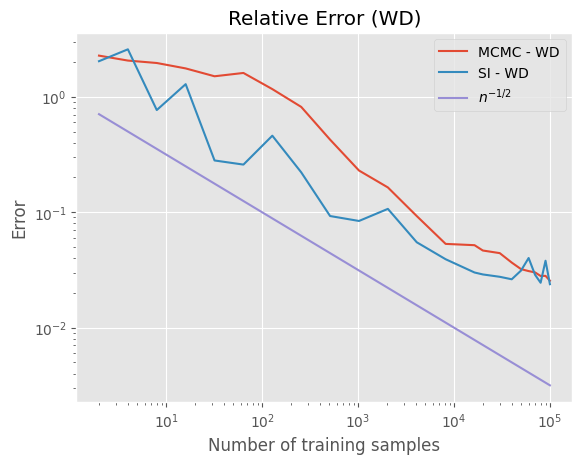

In [13]:
plt.plot(sample_no_list, rel_wd_array_mcmc, label="MCMC - WD")
plt.plot(sample_no_list, wd_array, label="SI - WD")
plt.plot(sample_no_list, 1 / np.sqrt(sample_no_list), label=r"$n^{-1/2}$")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Number of training samples")
plt.ylabel("Error")
plt.title("Relative Error (WD)")
plt.legend()

In [ ]:
wd_array

array([2.03515264, 2.57927058, 0.7678612 , 1.2871337 , 0.28079184,
       0.2586103 , 0.46025409, 0.221647  , 0.09265994, 0.0839848 ,
       0.10689823, 0.05489624, 0.03913474, 0.03003656, 0.02889414,
       0.02756985, 0.02623727, 0.03121787, 0.04010018, 0.02870683,
       0.02447478, 0.0379843 , 0.02377955])

: 

In [14]:
log_n = np.log(sample_no_list)
log_err = np.log(wd_array)

mask = np.array(sample_no_list) >= 1000
slope, intercept = np.polyfit(log_n[mask], log_err[mask], deg=1)

print("slope = ", slope)
print("intercept = ", intercept)

slope =  -0.26385662598897686
intercept =  -0.6614090901957204
